#  **Malaria Supply chain analytics project: Exploratory data analysis**

The purpose of this project is to conduct exploratory data analysis on a provided data set. Our mission is to continue the investigation we began in the step of data preparation and perform further EDA on this data with the aim of learning more about the variables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns 

In [2]:
df=pd.read_csv('../data/requisitions_cleaned.csv')

In [3]:
df.head()

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit
0,PYRA-COMP,2025-05-01,HEALTH CENTER,290.0,22.0,10.0,980.0,NaN,NaN,313,2.0,1,DISTRICT25,TABLET
1,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET
2,ART-INJ,2025-07-01,HEALTH CENTER,1744.0,4.0,409.0,1508.0,NaN,7396.0,-978,681.0,5,DISTRICT28,VIAL
3,RDT,2025-04-01,HEALTH CENTER,3187.0,737.0,471.0,3934.0,NaN,NaN,345,340.0,25,DISTRICT2,PIECE
4,PYRA-COMP,2025-07-01,HEALTH CENTER,3665.0,0.0,706.0,2667.0,NaN,5338.0,-1042,332.0,1,DISTRICT23,TABLET


## Dealing with missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31742 entries, 0 to 31741
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          31742 non-null  object 
 1   processing_periods_name       31742 non-null  object 
 2   facility_type_name            31742 non-null  object 
 3   beginning_balance             31742 non-null  float64
 4   quantity_received             31742 non-null  float64
 5   quantity_dispensed            31742 non-null  float64
 6   stock_in_hand                 31742 non-null  float64
 7   quantity_requested            8751 non-null   float64
 8   quantity_approved             25782 non-null  float64
 9   total_losses_and_adjustments  31742 non-null  int64  
 10  amc                           31742 non-null  float64
 11  pack_size                     31742 non-null  int64  
 12  zone                          31742 non-null  object 
 13  d

Event though the df.info() does not show missing values, we can observe that the columns **quantity_requested** 
and **quantity_approved** have missing values. 
* As explained during the data preparation phase, this is not necessarily a data quality issue.
It could be instead business logic related issue. eg. The NaN or empty values in the quantityrequested means that the facility did not place an order and the associated quantityapproved could also be empty if the approval team is OK with the decision
* However it could be a data quality issue if the quantityrequested is not empty and the quantityapproved is empty. But for keeping things simple we will consider that the NaN is quantityapproved means 0 since Pandas functions handle NaN properly: `sum()` and `means()` ignores NaN 

In [5]:
df.describe()

,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size
count,31742.000000,31742.000000,31742.000000,31742.000000,8751.000000,25782.000000,31742.000000,31742.000000,31742.000000
mean,1174.268288,202.350387,305.365604,1136.714133,762.121815,827.806415,-4.943009,253.131214,184.765957
std,1449.199817,470.726527,352.912528,1372.235556,498.749318,2034.067923,428.530698,352.885664,366.273133
min,0.000000,0.000000,0.000000,1.000000,17.000000,0.000000,-1903.000000,0.000000,1.000000
25%,203.000000,0.000000,62.000000,201.000000,398.000000,1.000000,-293.000000,28.000000,5.000000
50%,662.000000,17.000000,185.000000,660.000000,654.000000,44.000000,-4.000000,119.000000,30.000000
75%,1592.000000,170.000000,425.000000,1565.000000,1009.000000,607.000000,285.000000,339.000000,50.000000
max,19998.000000,7090.000000,4337.000000,16988.000000,4061.000000,52652.000000,1719.000000,4327.000000,1000.000000


## Data visualization

We will use data visualization to understand their distributions and assess them

### Beginning Balance

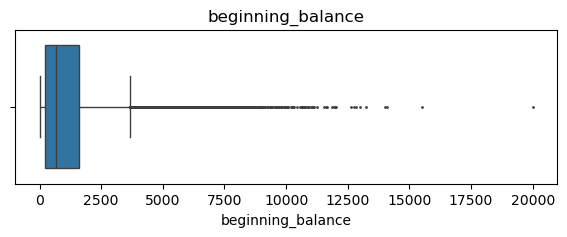

In [6]:
# Create box plot of beginning_balance
plt.figure(figsize=(7,2))
plt.title('beginning_balance')
sns.boxplot(data=None, x=df['beginning_balance'], fliersize=1);

#### Quantification of the outliers detection

In [7]:
percentile75=1592
percentile25=203
IQR=percentile75-percentile25
upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR
print ('Outlier threshold upper limit',upper_limit)
print('Outlier threshold lower limit',lower_limit)

Outlier threshold upper limit 3675.5
Outlier threshold lower limit -1880.5


* The distribution of beginning_balance exhibits a strong right-skewed pattern, indicating that stock levels are not evenly distributed across observations. Based on the descriptive statistics, the interquartile range (IQR) lies approximately between 203 (25th percentile) and 1592 (75th percentile), with a median of 662 units. This suggests that at least 50% of facilities begin the reporting period with stock levels between ~200 and ~1,600 units.
* However, the presence of extreme values extending up to ~20,000 units—far beyond the upper quartile—creates a pronounced long right tail. From a purely statistical perspective, these would be classified as outliers as the value is > 3675.5 (Upper limit). In the dataset, a significant number of observations exceed this threshold, confirming the heavy-tailed distribution
* From a supply chain perspective, these high values should not be interpreted as anomalies by default. Instead, they reflect structural heterogeneity within the system. Facilities operate at different levels (e.g., health centers vs. district or regional hospitals), leading to substantial variation in stockholding capacity. Products are distributed in different dispensing units and pack sizes, ranging from small units (e.g., blister packs of 30 tablets) to bulk formats (e.g., cartons containing up to 1000 tablets). As a result, identical “quantities” in reporting terms may correspond to vastly different physical volumes, inflating values for certain products.

**Outliers in this dataset are STRUCTURAL, not necessarily ERRORS**

Given that quantities are expressed in dispensing units (e.g., tablets, vials, pieces), a more appropriate approach is to analyze outliers within homogeneous groups defined by product, dispensing unit, and facility type.

#### Outlier detection by category

Based on the recommendation above we will analyze the outlier by products group of same dispensing unit and by facility type.
Products will be group below based on they homogeneity:
* ACT-AD

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

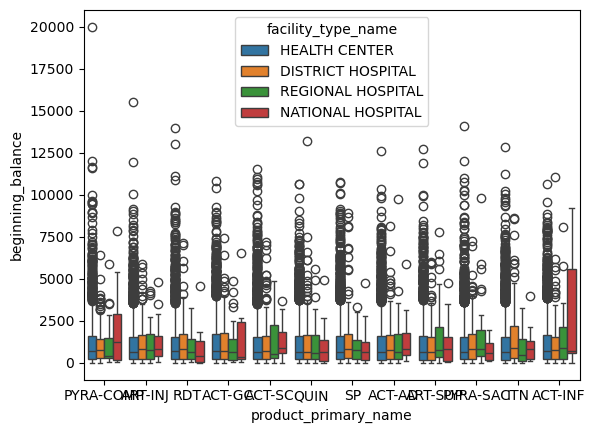

In [9]:
sns.boxplot(
    data=df,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

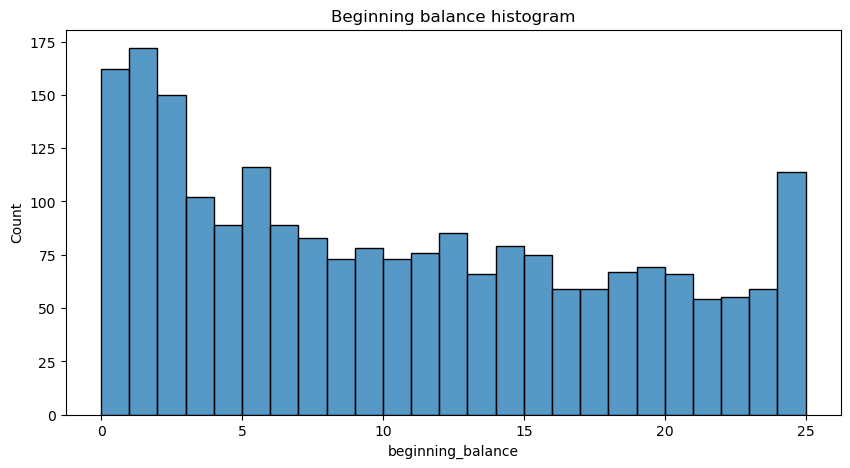

In [7]:
# Create the histogram of beginning_balance
plt.figure(figsize=(10,5))
sns.histplot(df['beginning_balance'], bins=range(0,26,1))
plt.title('Beginning balance histogram');